NDVI analysis complete!


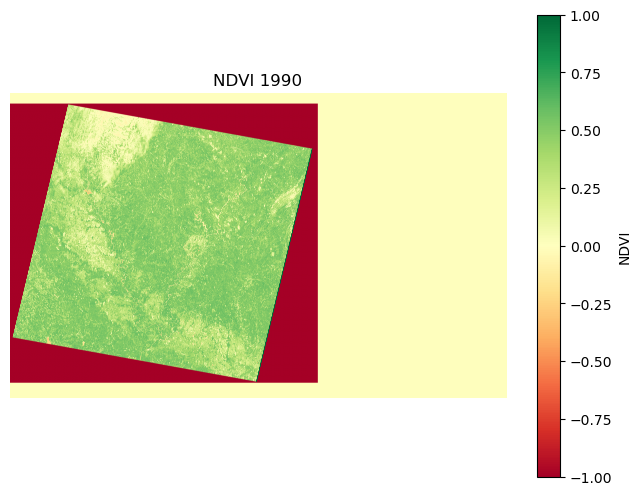

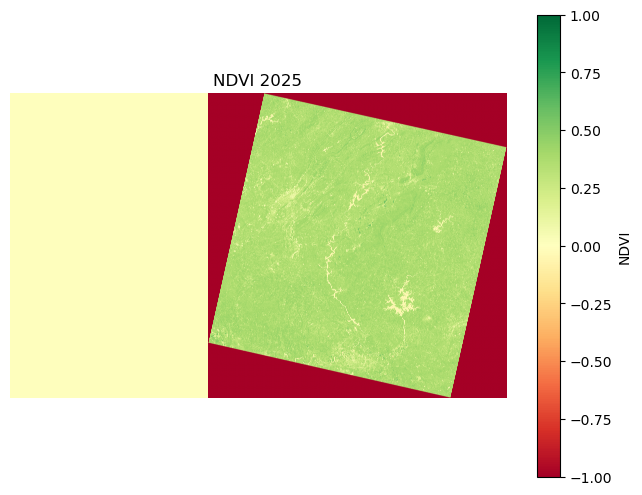

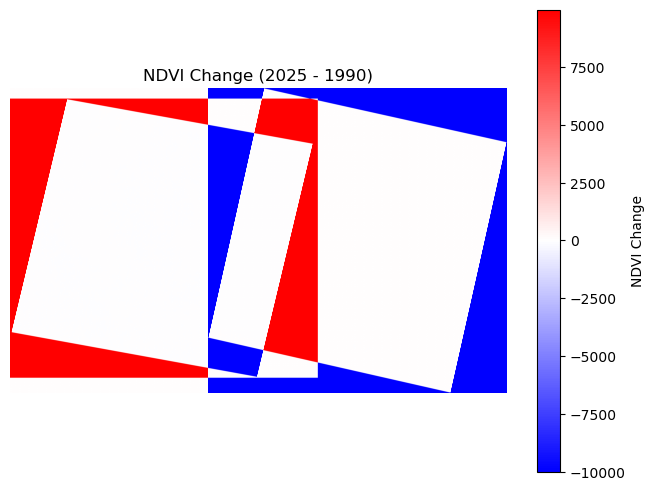

In [1]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from rasterio.warp import reproject, Resampling
from rasterio.transform import from_bounds

# FILE PATHS

red_1990_path = r"C:\Users\kaitl\Documents\408_AES\Final Project\LT05_L1TP_021037_19901009_20200915_02_T1\LT05_L1TP_021037_19901009_20200915_02_T1_B3.TIF"
nir_1990_path = r"C:\Users\kaitl\Documents\408_AES\Final Project\LT05_L1TP_021037_19901009_20200915_02_T1\LT05_L1TP_021037_19901009_20200915_02_T1_B4.TIF"

red_2025_path = r"C:\Users\kaitl\Documents\408_AES\Final Project\LC08_L1TP_020037_20250916_20250929_02_T1\LC08_L1TP_020037_20250916_20250929_02_T1_B4.TIF"
nir_2025_path = r"C:\Users\kaitl\Documents\408_AES\Final Project\LC08_L1TP_020037_20250916_20250929_02_T1\LC08_L1TP_020037_20250916_20250929_02_T1_B5.TIF"

# FUNCTION: READ RASTER

def read_raster(path):
    with rasterio.open(path) as src:
        data = src.read(1).astype(np.float32)
        transform = src.transform
        crs = src.crs
        bounds = src.bounds
        profile = src.profile
    return data, transform, crs, bounds, profile

# LOAD DATA

red_1990, t1990, crs1990, bounds1990, profile_1990 = read_raster(red_1990_path)
nir_1990, _, _, _, _ = read_raster(nir_1990_path)

red_2025, t2025, crs2025, bounds2025, profile_2025 = read_raster(red_2025_path)
nir_2025, _, _, _, _ = read_raster(nir_2025_path)

# CREATE SHARED GRID (UNION EXTENT)

minx = min(bounds1990.left, bounds2025.left)
miny = min(bounds1990.bottom, bounds2025.bottom)
maxx = max(bounds1990.right, bounds2025.right)
maxy = max(bounds1990.top, bounds2025.top)

# Use a consistent resolution (30m for Landsat)
resolution = abs(t1990.a)

width = int((maxx - minx) / resolution)
height = int((maxy - miny) / resolution)

shared_transform = from_bounds(minx, miny, maxx, maxy, width, height)

# FUNCTION: ALIGN TO GRID

def align_to_grid(source, src_transform, src_crs, dst_transform, dst_crs, width, height):
    aligned = np.empty((height, width), dtype=np.float32)

    reproject(
        source=source,
        destination=aligned,
        src_transform=src_transform,
        src_crs=src_crs,
        dst_transform=dst_transform,
        dst_crs=dst_crs,
        resampling=Resampling.bilinear,
        dst_nodata=-9999
    )

    return aligned

# ALIGN BOTH DATASETS TO SHARED GRID

red_1990_aligned = align_to_grid(red_1990, t1990, crs1990, shared_transform, crs1990, width, height)
nir_1990_aligned = align_to_grid(nir_1990, t1990, crs1990, shared_transform, crs1990, width, height)

red_2025_aligned = align_to_grid(red_2025, t2025, crs2025, shared_transform, crs2025, width, height)
nir_2025_aligned = align_to_grid(nir_2025, t2025, crs2025, shared_transform, crs2025, width, height)

# NDVI FUNCTION

def calculate_ndvi(red, nir):
    np.seterr(divide='ignore', invalid='ignore')
    ndvi = (nir - red) / (nir + red)
    return np.nan_to_num(ndvi, nan=-9999)

# CALCULATE NDVI

ndvi_1990 = calculate_ndvi(red_1990_aligned, nir_1990_aligned)
ndvi_2025 = calculate_ndvi(red_2025_aligned, nir_2025_aligned)

# NDVI CHANGE

ndvi_change = ndvi_2025 - ndvi_1990

# OUTPUT PROFILE

profile_out = profile_1990.copy()
profile_out.update(
    transform=shared_transform,
    width=width,
    height=height,
    dtype=rasterio.float32,
    count=1,
    nodata=-9999
)

# SAVE FILES as Geotiffs

ndvi_1990_out = r"C:\Users\kaitl\Documents\408_AES\Final Project\ndvi_1990.tif"
ndvi_2025_out = r"C:\Users\kaitl\Documents\408_AES\Final Project\ndvi_2025.tif"
ndvi_change_out = r"C:\Users\kaitl\Documents\408_AES\Final Project\ndvi_change.tif"

with rasterio.open(ndvi_1990_out, "w", **profile_out) as dst:
    dst.write(ndvi_1990.astype(rasterio.float32), 1)

with rasterio.open(ndvi_2025_out, "w", **profile_out) as dst:
    dst.write(ndvi_2025.astype(rasterio.float32), 1)

with rasterio.open(ndvi_change_out, "w", **profile_out) as dst:
    dst.write(ndvi_change.astype(rasterio.float32), 1)

print("NDVI analysis complete!")

# VISUALIZATION

plt.figure(figsize=(8,6))
plt.imshow(ndvi_1990, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(label="NDVI")
plt.title("NDVI 1990")
plt.axis("off")
plt.show()

plt.figure(figsize=(8,6))
plt.imshow(ndvi_2025, cmap="RdYlGn", vmin=-1, vmax=1)
plt.colorbar(label="NDVI")
plt.title("NDVI 2025")
plt.axis("off")
plt.show()

plt.figure(figsize=(8,6))
plt.imshow(ndvi_change, cmap="bwr")
plt.colorbar(label="NDVI Change")
plt.title("NDVI Change (2025 - 1990)")
plt.axis("off")
plt.show()

In [ ]:
# Images are not fully aligned yet, but I am going to download completely new Landsat data for my future time series

# LLM Source of assistance: ChatGPT

# This code is analyzing changes between 1990 and 2025. It is not my full time series project. 